# Loom Decoder Types

Every field in a `LoomModel` is backed by a **decoder type** — a small
object that knows how to map a slice of raw logits to a typed value,
compute a type-aware loss, and encode values back into logit space.

This notebook walks through each of the five built-in types with
interactive visualizations, then shows them working together in a
compiled head using the `loomlib.viz` plotting API.

In [1]:
%matplotlib inline

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from loomlib import (
    LoomModel, LoomUnion, LoomCompiler,
    Categorical, Boolean, ContinuousScalar, Scalar, BitInteger,
)
from loomlib.viz import (
    plot_allocation, plot_logits, plot_decoded, plot_loss_breakdown,
)

torch.manual_seed(42)

---
## 1. What is a LoomType?

Every decoder type implements four methods:

| Method | Purpose |
|---|---|
| `logit_size()` | How many raw logits this type consumes from the vector |
| `decode(z)` | Activation function: logits &rarr; typed value |
| `loss(z, target)` | Type-aware loss function |
| `encode(value)` | Reverse mapping: value &rarr; logit-shaped tensor |

### Type summary

| Type | Logits | Activation | Loss | Output |
|---|---|---|---|---|
| `Categorical(n)` | n | softmax &rarr; argmax | Cross-entropy | Class index |
| `Boolean()` | 1 | sigmoid &rarr; threshold | BCE | True / False |
| `ContinuousScalar(lo, hi)` | 1 | tanh &rarr; affine | MSE | Float in [lo, hi] |
| `Scalar()` | 1 | identity | MSE | Unbounded float |
| `BitInteger(B)` | B | per-bit sigmoid | BCE + &gamma;&middot;MSE | Integer in [0, 2^B) |

---
## 2. Categorical

**Softmax activation, cross-entropy loss.**  
Consumes `n` logits for `n` classes. Decoding takes the argmax;
the full probability distribution is available via `decode_probs()`.

Logit size: 6


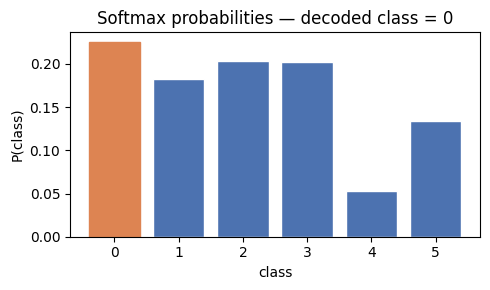

In [2]:
cat = Categorical(6)
print(f"Logit size: {cat.logit_size()}")

z = torch.randn(6)
probs = cat.decode_probs(z)
chosen = cat.decode(z)

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(range(6), probs.detach().numpy(), color="#4C72B0", edgecolor="white")
bars[chosen.item()].set_color("#DD8452")
ax.set_xlabel("class")
ax.set_ylabel("P(class)")
ax.set_title(f"Softmax probabilities — decoded class = {chosen.item()}")
ax.set_xticks(range(6))
plt.tight_layout()

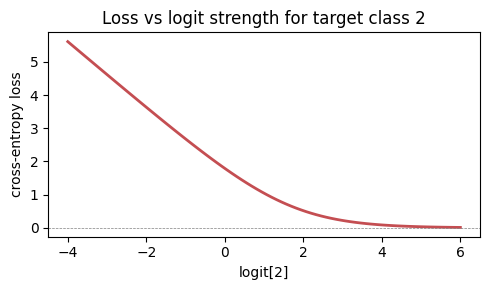

In [3]:
target_class = 2
sweeps = torch.linspace(-4, 6, 80)
losses = []
for s in sweeps:
    z_sweep = torch.zeros(6)
    z_sweep[target_class] = s
    losses.append(cat.loss(z_sweep, torch.tensor(target_class)).item())

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(sweeps.numpy(), losses, color="#C44E52", linewidth=2)
ax.set_xlabel(f"logit[{target_class}]")
ax.set_ylabel("cross-entropy loss")
ax.set_title(f"Loss vs logit strength for target class {target_class}")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
plt.tight_layout()

In [4]:
encoded = cat.encode(3)
print(f"encode(3) = {encoded}  (one-hot, shape {encoded.shape})")

encode(3) = tensor([0., 0., 0., 1., 0., 0.])  (one-hot, shape torch.Size([6]))


---
## 3. Boolean

**Sigmoid activation, BCE loss.**  
A single logit. Positive logits decode to `True`, negative to `False`,
with the decision boundary at 0 (sigmoid = 0.5).

Logit size: 1


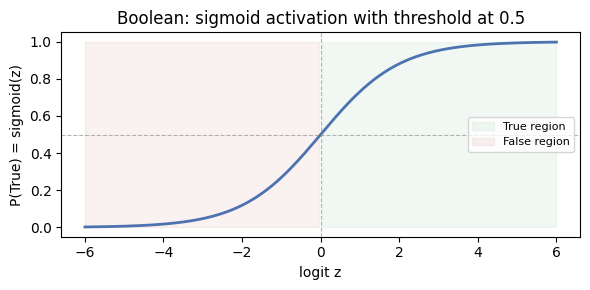

In [5]:
boolean = Boolean()
print(f"Logit size: {boolean.logit_size()}")

z_sweep = torch.linspace(-6, 6, 200)
sigmoid = torch.sigmoid(z_sweep)

fig, ax = plt.subplots(figsize=(6, 3))
ax.fill_between(z_sweep.numpy(), 0, 1, where=z_sweep.numpy() >= 0,
                alpha=0.08, color="#55A868", label="True region")
ax.fill_between(z_sweep.numpy(), 0, 1, where=z_sweep.numpy() < 0,
                alpha=0.08, color="#C44E52", label="False region")
ax.plot(z_sweep.numpy(), sigmoid.numpy(), color="#4C72B0", linewidth=2)
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_xlabel("logit z")
ax.set_ylabel("P(True) = sigmoid(z)")
ax.set_title("Boolean: sigmoid activation with threshold at 0.5")
ax.legend(fontsize=8)
plt.tight_layout()

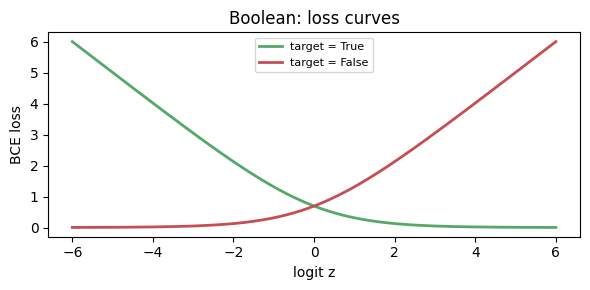

In [6]:
z_range = torch.linspace(-6, 6, 200)
loss_true = [boolean.loss(z.reshape(1), torch.tensor(1.0)).item() for z in z_range]
loss_false = [boolean.loss(z.reshape(1), torch.tensor(0.0)).item() for z in z_range]

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(z_range.numpy(), loss_true, color="#55A868", linewidth=2, label="target = True")
ax.plot(z_range.numpy(), loss_false, color="#C44E52", linewidth=2, label="target = False")
ax.set_xlabel("logit z")
ax.set_ylabel("BCE loss")
ax.set_title("Boolean: loss curves")
ax.legend(fontsize=8)
plt.tight_layout()

---
## 4. ContinuousScalar

**Tanh + affine activation, MSE loss.**  
Maps a single logit to a bounded range `[lo, hi]` via:

$$\text{value} = \text{midpoint} + \text{halfrange} \cdot \tanh(z)$$

Extreme logits saturate at the bounds; values near the midpoint
have the highest gradient sensitivity.

Logit size: 1, range: [-40.0, 85.0]
Midpoint: 22.5, halfrange: 62.5


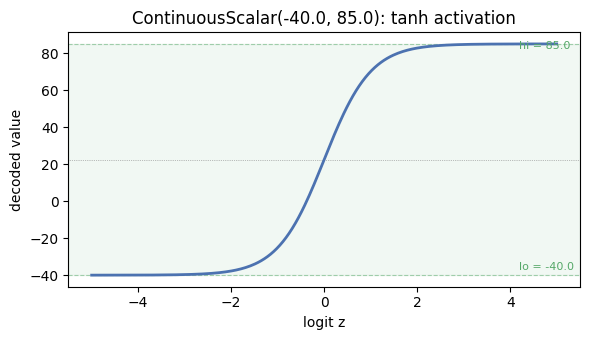

In [7]:
cs = ContinuousScalar(-40.0, 85.0)
print(f"Logit size: {cs.logit_size()}, range: [{cs._lo}, {cs._hi}]")
print(f"Midpoint: {cs.midpoint}, halfrange: {cs.halfrange}")

z_sweep = torch.linspace(-5, 5, 300)
values = cs.decode(z_sweep.unsqueeze(-1))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.axhspan(cs._lo, cs._hi, alpha=0.08, color="#55A868")
ax.axhline(cs._lo, color="#55A868", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axhline(cs._hi, color="#55A868", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axhline(cs.midpoint, color="gray", linewidth=0.5, linestyle=":")
ax.plot(z_sweep.numpy(), values.detach().numpy(), color="#4C72B0", linewidth=2)
ax.set_xlabel("logit z")
ax.set_ylabel("decoded value")
ax.set_title(f"ContinuousScalar({cs._lo}, {cs._hi}): tanh activation")
ax.text(4.2, cs._hi - 3, f"hi = {cs._hi}", fontsize=8, color="#55A868")
ax.text(4.2, cs._lo + 3, f"lo = {cs._lo}", fontsize=8, color="#55A868")
plt.tight_layout()

In [8]:
original = 25.0
encoded = cs.encode(original)
decoded = cs.decode(encoded)
print(f"encode({original}) = logit {encoded.item():.4f}")
print(f"decode(logit)     = {decoded.item():.4f}  (round-trip error: {abs(decoded.item() - original):.6f})")

encode(25.0) = logit 0.0400
decode(logit)     = 25.0000  (round-trip error: 0.000000)


---
## 5. Scalar

**Identity activation, MSE loss.**  
The simplest type: the raw logit *is* the value, with no bounding.
Use `ContinuousScalar` when you need guaranteed bounds; use `Scalar`
when the value range is unknown or genuinely unbounded.

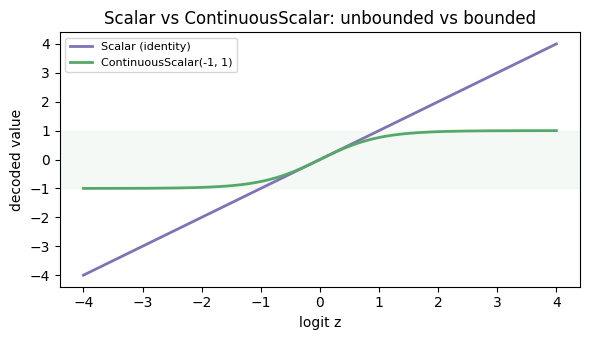

In [9]:
sc = Scalar()
cs2 = ContinuousScalar(-1.0, 1.0)

z_sweep = torch.linspace(-4, 4, 300)
scalar_vals = sc.decode(z_sweep.unsqueeze(-1))
cscalar_vals = cs2.decode(z_sweep.unsqueeze(-1))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.axhspan(cs2._lo, cs2._hi, alpha=0.06, color="#55A868")
ax.plot(z_sweep.numpy(), scalar_vals.detach().numpy(),
        color="#8172B3", linewidth=2, label="Scalar (identity)")
ax.plot(z_sweep.numpy(), cscalar_vals.detach().numpy(),
        color="#55A868", linewidth=2, label="ContinuousScalar(-1, 1)")
ax.set_xlabel("logit z")
ax.set_ylabel("decoded value")
ax.set_title("Scalar vs ContinuousScalar: unbounded vs bounded")
ax.legend(fontsize=8)
plt.tight_layout()

---
## 6. BitInteger

**Per-bit sigmoid encoding, dual-objective loss.**  
An integer in `[0, 2^B)` is represented as `B` independent logits,
one per bit. Each logit is decoded via sigmoid (probability that the
bit is 1), then thresholded at 0.5 for the hard decode.

The loss combines:
- **Bitwise BCE** — each bit gets its own binary cross-entropy
- **Magnitude MSE** — `gamma * MSE(soft_decode, target)` provides a
  global gradient signal even when individual bits are far from correct

In [10]:
bi = BitInteger(8)
print(f"Logit size: {bi.logit_size()}, range: [0, {2**8 - 1}]")

target_val = 42
encoded = bi.encode(target_val)
print(f"\nencode({target_val}) = {encoded}")
print(f"Bit weights: {bi._weights}")
print(f"Check: {int((encoded * bi._weights).sum().item())} == {target_val}")

Logit size: 8, range: [0, 255]

encode(42) = tensor([0., 1., 0., 1., 0., 1., 0., 0.])
Bit weights: tensor([  1.,   2.,   4.,   8.,  16.,  32.,  64., 128.])
Check: 42 == 42


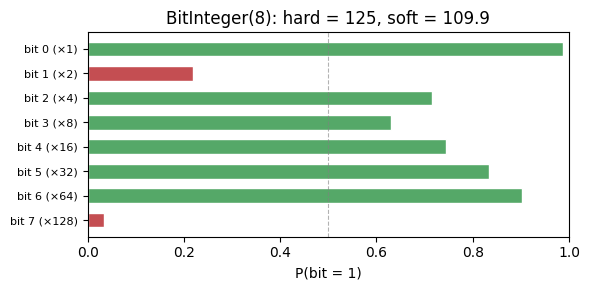

In [11]:
z_bits = torch.randn(8) * 2
bit_probs = torch.sigmoid(z_bits)
hard_decode = bi.decode(z_bits)
soft_decode = bi.decode_soft(z_bits)

fig, ax = plt.subplots(figsize=(6, 3))
positions = np.arange(8)
colors = ["#55A868" if p > 0.5 else "#C44E52" for p in bit_probs]
ax.barh(positions, bit_probs.detach().numpy(), color=colors, edgecolor="white", height=0.6)
ax.axvline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_yticks(positions)
ax.set_yticklabels([f"bit {i} (×{2**i})" for i in range(8)], fontsize=8)
ax.set_xlabel("P(bit = 1)")
ax.set_xlim(0, 1)
ax.set_title(f"BitInteger(8): hard = {hard_decode.item()}, soft = {soft_decode.item():.1f}")
ax.invert_yaxis()
plt.tight_layout()

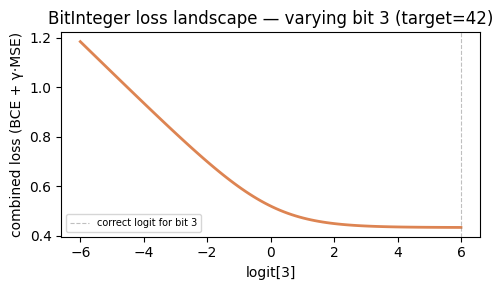

In [12]:
target = torch.tensor(42)
target_bits = bi.encode(42)

# Vary bit-3 logit while keeping the others at their target values
base_logits = target_bits * 6.0  # strong correct logits
bit_idx = 3
sweep = torch.linspace(-6, 6, 100)
losses = []
for s in sweep:
    z = base_logits.clone()
    z[bit_idx] = s
    losses.append(bi.loss(z, target).item())

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(sweep.numpy(), losses, color="#DD8452", linewidth=2)
correct_val = target_bits[bit_idx].item()
ax.axvline(6.0 * (2 * correct_val - 1), color="gray", linewidth=0.8,
           linestyle="--", alpha=0.5, label=f"correct logit for bit {bit_idx}")
ax.set_xlabel(f"logit[{bit_idx}]")
ax.set_ylabel("combined loss (BCE + γ·MSE)")
ax.set_title(f"BitInteger loss landscape — varying bit {bit_idx} (target={target.item()})")
ax.legend(fontsize=7)
plt.tight_layout()

---
## 7. All types together — loomlib.viz

Now we define a schema that uses every type, compile it into a
`LoomHead`, and use the `loomlib.viz` API to visualize the logit
allocation, raw logits, decoded values, and per-field loss breakdown.

In [13]:
class DemoModel(LoomModel):
    action: Categorical[4]
    active: bool
    temperature: ContinuousScalar[-40, 85]
    raw_signal: float
    error_code: BitInteger[8]

head = LoomCompiler.build_head(DemoModel, d_model=128)
print(f"Total logits: {head.total_logits}")
print(f"Fields: {dict(DemoModel.loom_fields())}")

Total logits: 15
Fields: {'action': Categorical(4), 'active': Boolean(), 'temperature': ContinuousScalar(-40.0, 85.0), 'raw_signal': Scalar(), 'error_code': BitInteger(8)}


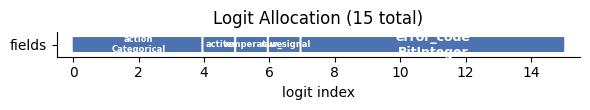

In [14]:
plot_allocation(head);

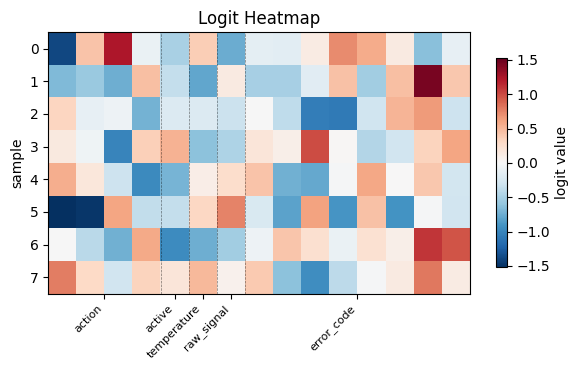

In [15]:
hidden = torch.randn(8, 128)
z = head(hidden)

plot_logits(head, z);

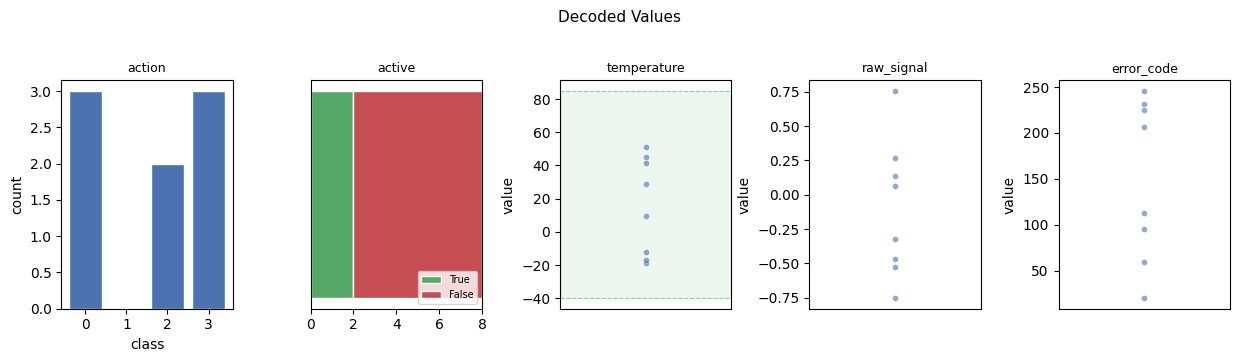

In [16]:
plot_decoded(head, z);

In [18]:
targets = {
    "action": torch.randint(0, 4, (8,)),
    "active": torch.randint(0, 2, (8,)).float(),
    "temperature": torch.FloatTensor(8).uniform_(-40, 85),
    "raw_signal": torch.randn(8) * 10,
    "error_code": torch.randint(0, 256, (8,)),
}

target_logits = head.encode(targets)

total_loss, breakdown = head.loss(z, targets)
print(f"Total loss: {total_loss.item():.4f}")

plot_loss_breakdown(breakdown, allocation=head.allocation);

AttributeError: 'LoomHead' object has no attribute 'encode'

---
## 8. Union bonus — opcode + per-branch layout

A `LoomUnion` adds an **opcode** slice (`Categorical(num_branches)`)
at the front of the logit vector, followed by each branch's fields.
The gradient mask ensures only the active branch's logits are trained
for a given sample.

In [ ]:
class MoveAction(LoomModel):
    direction: Categorical[4]
    speed: ContinuousScalar[0.0, 10.0]

class CastSpell(LoomModel):
    spell_id: Categorical[6]
    power: BitInteger[8]

class AgentAction(LoomUnion):
    move: MoveAction
    cast: CastSpell

union_head = LoomCompiler.build_head(AgentAction, d_model=128)
print(f"Total logits: {union_head.total_logits}")
print(f"Branches: {AgentAction.branch_names()}")

plot_allocation(union_head);

In [ ]:
z_union = union_head(torch.randn(6, 128))
decoded = union_head.decode(z_union)

print("Decoded fields:")
for k, v in decoded.items():
    print(f"  {k}: {v}")

plot_logits(union_head, z_union);